<a href="https://colab.research.google.com/github/jas2005-rgb/pppp/blob/main/flaged_Plagiarism_NLP_Project(3_files).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
!pip install nltk scikit-learn

In [26]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Download required NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')   # Required for newer NLTK versions
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [27]:
documents = [
    """
    Artificial intelligence is changing the world.
    Machine learning is a branch of artificial intelligence.
    Natural language processing helps computers understand human language.
    """,

    """
    Artificial intelligence is transforming the world.
    Machine learning is a field of artificial intelligence.
    Natural language processing enables computers to understand human language.
    """,

    """
    Football is a popular sport.
    Many people enjoy watching football matches.
    Players train every day to improve their skills.
    """
]
print(documents)

['\n    Artificial intelligence is changing the world.\n    Machine learning is a branch of artificial intelligence.\n    Natural language processing helps computers understand human language.\n    ', '\n    Artificial intelligence is transforming the world.\n    Machine learning is a field of artificial intelligence.\n    Natural language processing enables computers to understand human language.\n    ', '\n    Football is a popular sport.\n    Many people enjoy watching football matches.\n    Players train every day to improve their skills.\n    ']


In [28]:
stop_words = set(stopwords.words("english"))

In [29]:
def preprocess_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize the text
    words = word_tokenize(text)

    # Remove stop words
    words = [word for word in words if word not in stop_words]

    # Join words back into a string
    return " ".join(words)

In [30]:
processed_documents = []

for doc in documents:
    processed_documents.append(preprocess_text(doc))

In [31]:
print("Original Documents:\n")

for doc in documents:
    print(doc)

print("\nProcessed Documents:\n")

for doc in processed_documents:
    print(doc)

Original Documents:


    Artificial intelligence is changing the world.
    Machine learning is a branch of artificial intelligence.
    Natural language processing helps computers understand human language.
    

    Artificial intelligence is transforming the world.
    Machine learning is a field of artificial intelligence.
    Natural language processing enables computers to understand human language.
    

    Football is a popular sport.
    Many people enjoy watching football matches.
    Players train every day to improve their skills.
    

Processed Documents:

artificial intelligence changing world machine learning branch artificial intelligence natural language processing helps computers understand human language
artificial intelligence transforming world machine learning field artificial intelligence natural language processing enables computers understand human language
football popular sport many people enjoy watching football matches players train every day improve ski

In [32]:
vocabulary = set()

for doc in processed_documents:

    words = doc.split()

    vocabulary.update(words)

vocabulary = sorted(vocabulary)

print(vocabulary)

['artificial', 'branch', 'changing', 'computers', 'day', 'enables', 'enjoy', 'every', 'field', 'football', 'helps', 'human', 'improve', 'intelligence', 'language', 'learning', 'machine', 'many', 'matches', 'natural', 'people', 'players', 'popular', 'processing', 'skills', 'sport', 'train', 'transforming', 'understand', 'watching', 'world']


In [33]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

bow_matrix = vectorizer.fit_transform(processed_documents)

print(vectorizer.get_feature_names_out())

print(bow_matrix.toarray())

['artificial' 'branch' 'changing' 'computers' 'day' 'enables' 'enjoy'
 'every' 'field' 'football' 'helps' 'human' 'improve' 'intelligence'
 'language' 'learning' 'machine' 'many' 'matches' 'natural' 'people'
 'players' 'popular' 'processing' 'skills' 'sport' 'train' 'transforming'
 'understand' 'watching' 'world']
[[2 1 1 1 0 0 0 0 0 0 1 1 0 2 2 1 1 0 0 1 0 0 0 1 0 0 0 0 1 0 1]
 [2 0 0 1 0 1 0 0 1 0 0 1 0 2 2 1 1 0 0 1 0 0 0 1 0 0 0 1 1 0 1]
 [0 0 0 0 1 0 1 1 0 2 0 0 1 0 0 0 0 1 1 0 1 1 1 0 1 1 1 0 0 1 0]]


In [34]:
import pandas as pd

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

print(tfidf_df)

   artificial    branch  changing  computers       day   enables     enjoy  \
0    0.398515  0.261999  0.261999   0.199257  0.000000  0.000000  0.000000   
1    0.398515  0.000000  0.000000   0.199257  0.000000  0.261999  0.000000   
2    0.000000  0.000000  0.000000   0.000000  0.242536  0.000000  0.242536   

      every     field  football  ...   players   popular  processing  \
0  0.000000  0.000000  0.000000  ...  0.000000  0.000000    0.199257   
1  0.000000  0.261999  0.000000  ...  0.000000  0.000000    0.199257   
2  0.242536  0.000000  0.485071  ...  0.242536  0.242536    0.000000   

     skills     sport     train  transforming  understand  watching     world  
0  0.000000  0.000000  0.000000      0.000000    0.199257  0.000000  0.199257  
1  0.000000  0.000000  0.000000      0.261999    0.199257  0.000000  0.199257  
2  0.242536  0.242536  0.242536      0.000000    0.000000  0.242536  0.000000  

[3 rows x 31 columns]


In [35]:
similarity = cosine_similarity(tfidf_matrix)
print("\nCosine Similarity Matrix\n")

print(similarity)


Cosine Similarity Matrix

[[1.         0.79406904 0.        ]
 [0.79406904 1.         0.        ]
 [0.         0.         1.        ]]


In [41]:
import numpy as np

# The 'similarity' variable is a 3x3 matrix.
# To create a 2x2 heatmap, you need to select a specific scalar similarity value.
# For example, let's use the similarity between the first two documents (index 0 and 1).
single_similarity_value = similarity[0, 1]  # Or choose any other relevant scalar value

heatmap_matrix = np.array([
    [1.0, single_similarity_value],
    [single_similarity_value, 1.0]
])

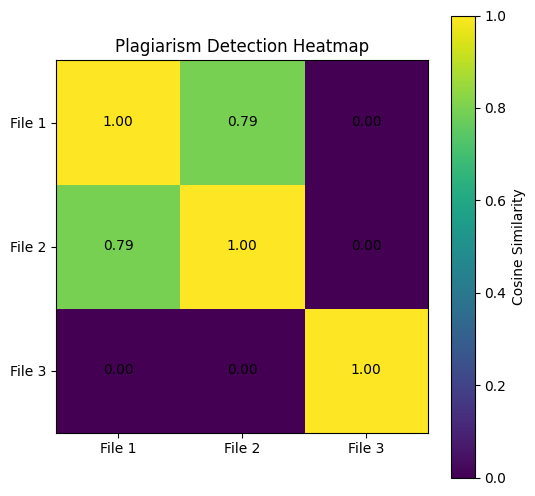

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Create cosine similarity matrix
heatmap_matrix = cosine_similarity(tfidf_matrix)

plt.figure(figsize=(6,6))

plt.imshow(heatmap_matrix)

# Labels for 3 files
labels = ["File 1", "File 2", "File 3"]

plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)

plt.colorbar(label="Cosine Similarity")

plt.title("Plagiarism Detection Heatmap")

# Display similarity values
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(
            j,
            i,
            f"{heatmap_matrix[i][j]:.2f}",
            ha="center",
            va="center"
        )

plt.show()

In [48]:
print("\nPlagiarism Report\n")

threshold = 0.75      # 70%

for i in range(len(documents)):
    for j in range(i + 1, len(documents)):

        score = similarity[i][j]

        print(f"Document {i+1} vs Document {j+1}")

        print(f"Similarity : {score*100:.2f}%")

        if score >= threshold:
            print("Status : 🚩 FLAGGED AS PLAGIARISM")

        else:
            print("Status : ✅ NOT PLAGIARIZED")

        print("-"*40)



Plagiarism Report

Document 1 vs Document 2
Similarity : 79.41%
Status : 🚩 FLAGGED AS PLAGIARISM
----------------------------------------
Document 1 vs Document 3
Similarity : 0.00%
Status : ✅ NOT PLAGIARIZED
----------------------------------------
Document 2 vs Document 3
Similarity : 0.00%
Status : ✅ NOT PLAGIARIZED
----------------------------------------
